<a href="https://colab.research.google.com/github/KweonTJ/Artifical_Intelligence-ML-NN-/blob/main/lec04_linear_regression_multivariate_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 다변량 선형 회귀 (Multivariate Linear Regression) 실습

이 실습에서는 Boston House 데이터셋을 사용하여 다변량 선형 회귀를 구현합니다:
1. scikit-learn의 LinearRegression 사용
2. scipy.optimize를 이용한 직접 구현

**총점: 100점**

**학번:** 2023042028\
**이름:** 권택주

---
## Part 1: 데이터 로드 및 탐색 (15점)

Boston House 데이터셋을 로드하고 탐색합니다.

---

### 문제 1-1. 데이터 로드 및 확인 [10점]

pickle 파일에서 Boston House 데이터를 로드하고 DataFrame으로 변환합니다.

**문제:** 데이터를 로드하고 DataFrame으로 변환하세요.

**예상 결과:** 506개 행, 14개 열 (13개 특성 + PRICE)

In [3]:
#@title { vertical-output: true}
import pickle
import pandas as pd

with open('./boston_house.pkl', 'rb') as f:
    boston_house = pickle.load(f)

bh = pd.DataFrame(boston_house.data, columns=boston_house.feature_names)
bh['PRICE'] = boston_house.target

display(bh)
print(f"데이터 크기: {bh.shape}")

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


데이터 크기: (506, 14)


### 문제 1-2. 데이터 시각화 [5점]

PRICE와 다른 특성들(DIS, LSTAT) 간의 관계를 시각화합니다.

**예상 결과:** 산점도 그래프

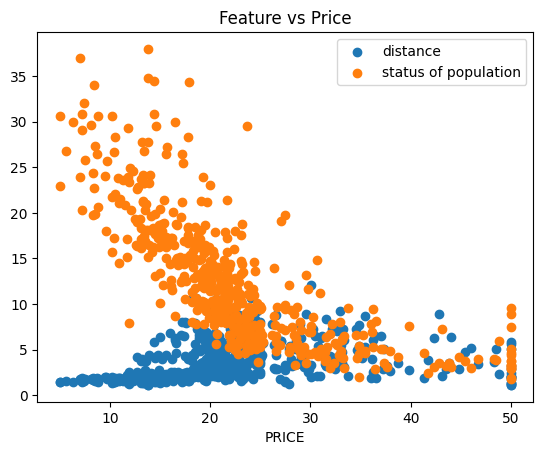

In [4]:
#@title { vertical-output: true}
import matplotlib.pyplot as plt

plt.scatter(bh['PRICE'], bh['DIS'], label='distance')
plt.scatter(bh['PRICE'], bh['LSTAT'], label='status of population')
plt.xlabel('PRICE')
plt.legend()
plt.title('Feature vs Price')
plt.show()

---
## Part 2: 데이터 전처리 (20점)

데이터를 훈련/테스트 세트로 분할하고 표준화(z-score normalization)를 수행합니다.

---

### 문제 2-1. 데이터 분할 [10점]

`train_test_split`을 사용하여 데이터를 훈련/테스트 세트로 분할합니다.

**설정:**
- test_size = 0.2
- random_state = 24

**문제:** train_test_split을 사용하여 데이터를 분할하세요.

**예상 결과:** 훈련 데이터 404개, 테스트 데이터 102개

In [13]:
#@title { vertical-output: true}
from sklearn.model_selection import train_test_split

x = boston_house['data']
y = boston_house['target']

# IMPLEMENT HERE: train_test_split 사용 (test_size=0.2, random_state=24)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"훈련 데이터: {x_train.shape[0]}개")
print(f"테스트 데이터: {x_test.shape[0]}개")

훈련 데이터: 404개
테스트 데이터: 102개


### 문제 2-2. Z-Score 표준화 [10점]

특성 데이터를 z-score 표준화합니다.

**공식:** $x_{normalized} = \frac{x - \mu}{\sigma}$

**주의:** 훈련 데이터의 평균과 표준편차를 사용하여 테스트 데이터도 변환해야 합니다.

**문제:** x_train과 x_test를 표준화하세요.

**예상 결과:** 표준화된 데이터의 산점도

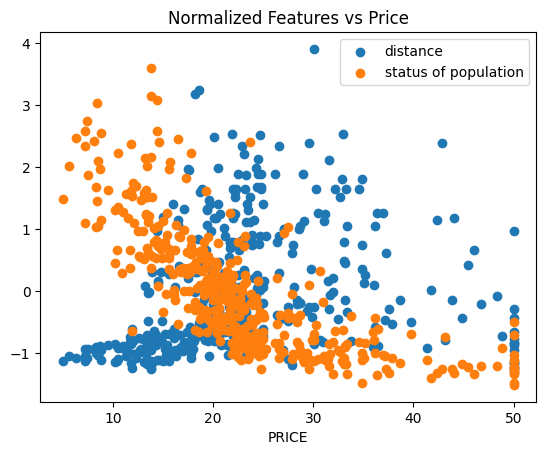

In [14]:
#@title { vertical-output: true}
# IMPLEMENT HERE: z-score 표준화
# x_offset = 훈련 데이터의 평균 (axis=0)
# x_scale = 훈련 데이터의 표준편차 (axis=0)
x_offset = x_train.mean(axis=0)
x_scale = x_train.std(axis=0)

# 표준화 적용
xm_train = (x_train - x_offset) / x_scale
xm_test = (x_test - x_offset) / x_scale

# 결과 시각화
bh_norm = pd.DataFrame(xm_train, columns=boston_house.feature_names)
bh_norm['PRICE'] = y_train
plt.scatter(bh_norm['PRICE'], bh_norm['DIS'], label='distance')
plt.scatter(bh_norm['PRICE'], bh_norm['LSTAT'], label='status of population')
plt.xlabel('PRICE')
plt.legend()
plt.title('Normalized Features vs Price')
plt.show()

---
## Part 3: scikit-learn LinearRegression (25점)

scikit-learn의 LinearRegression 모델을 사용합니다.

---

### 문제 3-1. LinearRegression 학습 및 평가 [25점]

scikit-learn의 LinearRegression을 사용하여 모델을 학습하고 평가합니다.

**문제:**
1. LinearRegression 모델을 생성하고 학습시키세요.
2. 테스트 데이터로 예측하고 MSE를 계산하세요.

**예상 결과:**
```
MSE: 약 24~25
```

In [15]:
#@title { vertical-output: true}
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# IMPLEMENT HERE
# 1. LinearRegression 모델 생성
model = LinearRegression()

# 2. 모델 학습 (fit)
model.fit(xm_train, y_train)

# 3. 테스트 데이터 예측 (predict)
y_pred_test = model.predict(xm_test)

# 4. MSE 계산
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'MSE: {mse_test:.4f}')

MSE: 24.2911


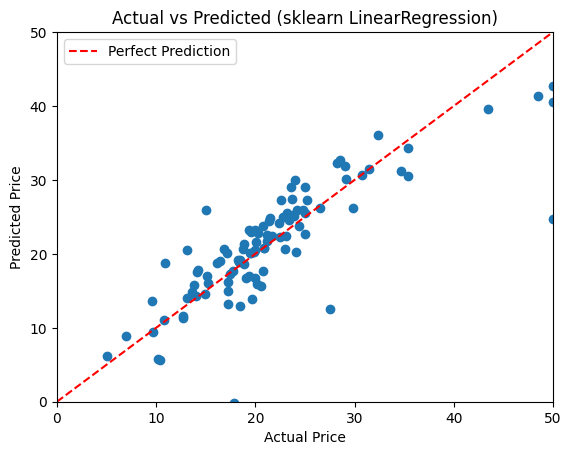

In [16]:
#@title { vertical-output: true}
# 예측 결과 시각화
plt.scatter(y_test, y_pred_test)
plt.plot([0, 50], [0, 50], 'r--', label='Perfect Prediction')
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (sklearn LinearRegression)')
plt.legend()
plt.show()

---
## Part 4: scipy.optimize를 이용한 선형 회귀 (40점)

scipy.optimize.minimize를 사용하여 선형 회귀를 직접 구현합니다.

**다변량 선형 회귀 모델:**
$$\hat{y} = W \cdot X^T + b = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

**손실 함수 (MSE):**
$$L(W, b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

---

### 문제 4-1. 손실 함수 구현 [20점]

다변량 선형 회귀의 손실 함수를 구현합니다.

**파라미터 구조:**
- params[:-1] = W (가중치 벡터)
- params[-1] = b (편향)

**문제:** `linear_regression` 함수에서 y_pred와 mse를 계산하세요.

**힌트:**
- y_pred = W @ X.T + b (행렬 곱셈 사용)
- mse = np.mean((y_pred - y)**2)

In [17]:
#@title { vertical-output: true}
import numpy as np
from scipy.optimize import minimize

def linear_regression(params, X, y):
    """
    다변량 선형 회귀 손실 함수

    Parameters:
    - params: [w1, w2, ..., wn, b] 파라미터 (n+1개)
    - X: 입력 데이터 (m x n)
    - y: 실제 값 (m,)

    Returns:
    - mse: Mean Squared Error
    """
    W = params[:-1]  # 가중치 벡터
    b = params[-1]   # 편향

    # IMPLEMENT HERE
    # y_pred = W @ X.T + b (행렬 곱셈)
    y_pred = W @ X.T + b

    # mse 계산
    mse = np.mean((y_pred - y)**2)

    return mse

### 문제 4-2. scipy.optimize.minimize 사용 [20점]

`scipy.optimize.minimize`를 사용하여 최적의 파라미터를 찾습니다.

**문제:** minimize 함수를 호출하여 최적의 W와 b를 찾으세요.

**힌트:**
```python
initial_guess = np.ones(xm_train.shape[1] + 1)  # 특성 개수 + 1 (bias)
result = minimize(linear_regression, initial_guess, args=(xm_train, y_train))
```

**예상 결과:**
```
MSE: 약 24~25 (sklearn과 유사)
```

In [18]:
#@title { vertical-output: true}
# IMPLEMENT HERE
# 1. 초기값 설정 (모든 파라미터를 1로)
initial_guess = np.ones(xm_train.shape[1] + 1)

# 2. minimize 함수 호출
result = minimize(linear_regression, initial_guess, args=(xm_train, y_train))

print(result)

# 최적 파라미터 추출
W_opt, b_opt = result.x[:-1], result.x[-1]
print(f"\n최적 편향 (b): {b_opt:.4f}")

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 21.641412753318505
        x: [-1.002e+00  6.963e-01 ... -3.612e+00  2.280e+01]
      nit: 19
      jac: [-7.153e-07  3.338e-06 ... -3.576e-06 -7.153e-07]
 hess_inv: [[ 8.723e-01 -1.244e-01 ... -4.737e-05  4.009e-03]
            [-1.244e-01  1.082e+00 ... -1.985e-03 -9.622e-03]
            ...
            [-4.737e-05 -1.985e-03 ...  1.146e+00 -4.216e-03]
            [ 4.009e-03 -9.622e-03 ... -4.216e-03  5.031e-01]]
     nfev: 315
     njev: 21

최적 편향 (b): 22.7965


MSE: 24.2911


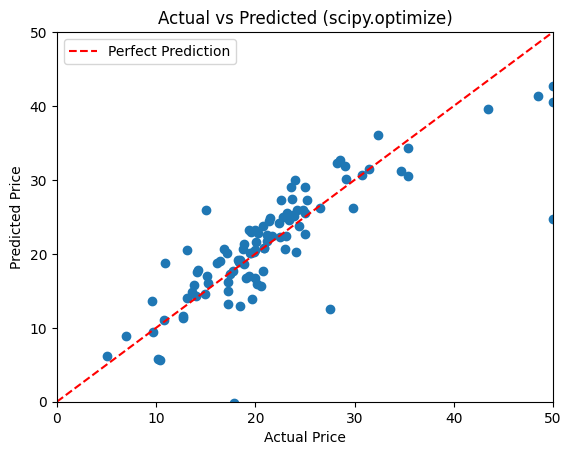

In [19]:
#@title { vertical-output: true}
# 테스트 데이터로 평가
y_pred_test = W_opt @ xm_test.T + b_opt
mse_test = mean_squared_error(y_test, y_pred_test)
print(f'MSE: {mse_test:.4f}')

# 결과 시각화
plt.scatter(y_test, y_pred_test)
plt.plot([0, 50], [0, 50], 'r--', label='Perfect Prediction')
plt.xlim(0, 50)
plt.ylim(0, 50)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted (scipy.optimize)')
plt.legend()
plt.show()

---
## 제출 안내

1. 모든 문제를 완성한 후, 코드 셀을 실행하여 결과를 확인하세요.
2. **제출 파일:**
   - `.ipynb` 파일
   - `.pdf` 파일 (파일 > 인쇄 > PDF로 저장)
3. 파일명: `linear_regression_multivariate_학번_이름.ipynb`, `linear_regression_multivariate_학번_이름.pdf`
4. LMS에 두 파일을 함께 제출하세요.

**주의:** 기한 내에 제출하지 않으면 감점이 있습니다.

---